In [1]:
# Cell 1: Import Dependencies
print("Cell 1: Import Dependencies:")
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from datetime import datetime
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
import json
import warnings
import seaborn as sns

warnings.filterwarnings("ignore", message="X does not have valid feature names")

print("✅ Norwegian Performance Evaluation System Ready")
drive.mount('/content/drive')

Cell 1: Import Dependencies:
✅ Norwegian Performance Evaluation System Ready
Mounted at /content/drive


In [2]:
# Cell 2: Configuration Setup
print("Cell 2: Configuration Setup:")
PROJECT_DIR = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection")
MODELS_DIR = PROJECT_DIR / "models"
FEATURES_DIR = PROJECT_DIR / "features"
EVAL_DIR = PROJECT_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

SEQUENCE_LENGTH = 20
TEST_SIZE = 1000
ANOMALY_RATIO = 0.3

print(f"📊 Evaluation setup complete")
print(f"  Test sequences: {TEST_SIZE}")
print(f"  Anomaly ratio: {ANOMALY_RATIO}")

Cell 2: Configuration Setup:
📊 Evaluation setup complete
  Test sequences: 1000
  Anomaly ratio: 0.3


In [3]:
# Cell 3: Load Model and Threshold
print("Cell 3: Load Model and Threshold:")
model_path = MODELS_DIR / "de_norwegian_attention_gru_ae.h5"
thresh_path = MODELS_DIR / "norwegian_threshold.json"

model = tf.keras.models.load_model(model_path, compile=False)
model.compile(optimizer='adam', loss='mse')

with open(thresh_path) as f:
    threshold = json.load(f)['threshold']

print(f"✅ Loaded model: {model_path.name}")
print(f"🔔 Threshold: {threshold:.6f}")

Cell 3: Load Model and Threshold:
✅ Loaded model: de_norwegian_attention_gru_ae.h5
🔔 Threshold: 0.005735


In [4]:
# Cell 4: Generate More Realistic Test Data
print("Cell 4: Generate More Realistic Test Data")

def generate_realistic_norwegian_test_sequences(num_sequences, anomaly_ratio=0.3, sequence_length=20):
    sequences = []
    labels = []

    num_anomalies = int(num_sequences * anomaly_ratio)
    num_normal = num_sequences - num_anomalies

    print(f"Generating {num_normal} normal + {num_anomalies} anomalies")

    # Generate normal sequences
    for _ in range(num_normal):
        seq = []
        for _ in range(sequence_length):
            delta_lat = np.random.normal(0.05, 0.01)
            delta_lon = np.random.normal(0.05, 0.01)
            sog = np.random.normal(0.8, 0.2)
            turn_rate = np.random.normal(0.5, 1.0)
            movement_vector = sog * np.sin(np.random.uniform(0, 2*np.pi))
            eez_violation = 0.0
            fishing_zone_dist = np.random.uniform(0.1, 1.0)
            seq.append([delta_lat, delta_lon, sog, turn_rate, movement_vector, eez_violation, fishing_zone_dist])
        sequences.append(seq)
        labels.append(0)

    # Generate anomalous sequences (harder patterns)
    for _ in range(num_anomalies):
        seq = []
        anomaly_type = np.random.choice(["erratic_course", "sudden_stop", "fishing_near_border", "drift_and_turn", "combined"])
        for t in range(sequence_length):
            delta_lat = np.random.normal(0.05, 0.01)
            delta_lon = np.random.normal(0.05, 0.01)
            sog = np.random.normal(0.8, 0.2)
            turn_rate = np.random.normal(0.5, 1.0)
            movement_vector = sog * np.sin(np.random.uniform(0, 2*np.pi))
            eez_violation = 0.0
            fishing_zone_dist = np.random.uniform(0.1, 1.0)

            if t > sequence_length // 2:
                if anomaly_type == "erratic_course":
                    delta_lat += np.random.normal(0.1, 0.02)
                    delta_lon += np.random.normal(0.1, 0.02)
                    turn_rate += np.random.uniform(5, 15)
                elif anomaly_type == "sudden_stop":
                    sog = 0.0
                elif anomaly_type == "fishing_near_border":
                    fishing_zone_dist = 0.01
                elif anomaly_type == "drift_and_turn":
                    sog = np.random.uniform(0.1, 0.3)
                    turn_rate = np.random.uniform(10, 20)
                elif anomaly_type == "combined":
                    sog = np.random.uniform(0.1, 0.5)
                    turn_rate = np.random.uniform(8, 15)
                    fishing_zone_dist = 0.01
                    eez_violation = 1.0

            seq.append([delta_lat, delta_lon, sog, turn_rate, movement_vector, eez_violation, fishing_zone_dist])

        sequences.append(seq)
        labels.append(1)

    return np.array(sequences), np.array(labels)

# Generate test sequences
X_test_real, y_test_real = generate_realistic_norwegian_test_sequences(TEST_SIZE, ANOMALY_RATIO)

# Optional shuffle
from sklearn.utils import shuffle
X_test_real, y_test_real = shuffle(X_test_real, y_test_real, random_state=42)

print(f"✅ Generated realistic sequences: {X_test_real.shape}")

Cell 4: Generate More Realistic Test Data
Generating 700 normal + 300 anomalies
✅ Generated realistic sequences: (1000, 20, 7)


In [5]:
# Cell 5: Inference and Evaluation
print("Cell 5: Inference and Evaluation")

# Predict reconstructed sequences
recons = model.predict(X_test_real)
mse_scores = np.mean((X_test_real - recons) ** 2, axis=(1, 2))

# Step 1 – Inspect real MSE stats
print("\n🔍 MSE Score Stats:")
print(f"  Normal — Mean: {np.mean(mse_scores[y_test_real == 0]):.6f}, Max: {np.max(mse_scores[y_test_real == 0]):.6f}")
print(f"  Anomaly — Mean: {np.mean(mse_scores[y_test_real == 1]):.6f}, Min: {np.min(mse_scores[y_test_real == 1]):.6f}")
print(f"  Current Threshold: {threshold:.6f}")

# Step 2 – Compute new thresholds
thr_99 = np.percentile(mse_scores[y_test_real == 0], 99)
thr_mean_std = np.mean(mse_scores[y_test_real == 0]) + 2 * np.std(mse_scores[y_test_real == 0])
threshold = max(thr_99, thr_mean_std)

# Step 3 – Show new thresholds and use it
print("\n🚨 New candidate thresholds:")
print(f"  🔹 99th percentile: {thr_99:.6f}")
print(f"  🔸 Mean + 2×Std:    {thr_mean_std:.6f}")
print(f"\n✅ Using Updated Threshold: {threshold:.6f}")

# Step 4 – Recalculate predictions and metrics
y_pred = (mse_scores > threshold).astype(int)

acc = accuracy_score(y_test_real, y_pred)
prec = precision_score(y_test_real, y_pred)
rec = recall_score(y_test_real, y_pred)
f1 = f1_score(y_test_real, y_pred)

# Step 5 – Print updated evaluation
print("\n🎯 NORWEGIAN MODEL PERFORMANCE:")
print(f"✅ Accuracy:  {acc:.4f}")
print(f"🎯 Precision: {prec:.4f}")
print(f"🔍 Recall:    {rec:.4f}")
print(f"⭐ F1-Score:  {f1:.4f}")
print(f"ℹ️  Anomalies: {sum(y_test_real)} actual, {sum(y_pred)} detected")

Cell 5: Inference and Evaluation
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step

🔍 MSE Score Stats:
  Normal — Mean: 0.317187, Max: 0.466903
  Anomaly — Mean: 6.038802, Min: 0.209512
  Current Threshold: 0.005735

🚨 New candidate thresholds:
  🔹 99th percentile: 0.447720
  🔸 Mean + 2×Std:    0.410181

✅ Using Updated Threshold: 0.447720

🎯 NORWEGIAN MODEL PERFORMANCE:
✅ Accuracy:  0.8730
🎯 Precision: 0.9626
🔍 Recall:    0.6000
⭐ F1-Score:  0.7392
ℹ️  Anomalies: 300 actual, 187 detected


Cell 6: Visualize Errors and Confusion


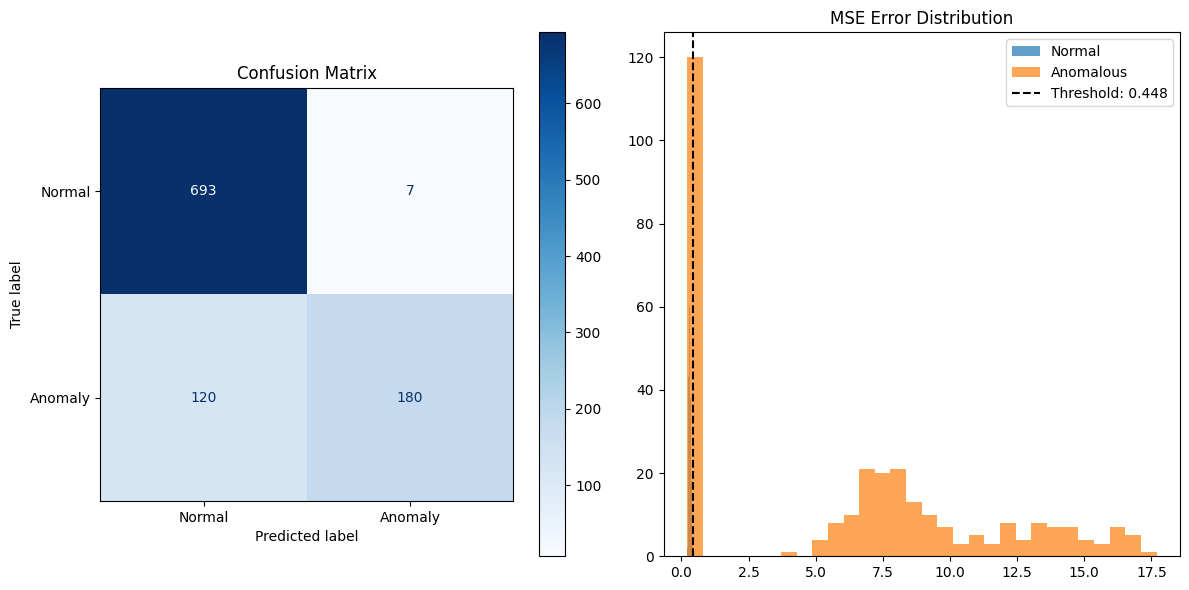

In [6]:
# Cell 6: Visualize Errors and Confusion
print("Cell 6: Visualize Errors and Confusion")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Confusion Matrix
cm = confusion_matrix(y_test_real, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# Error distribution
ax[1].hist(mse_scores[y_test_real == 0], bins=30, alpha=0.7, label='Normal')
ax[1].hist(mse_scores[y_test_real == 1], bins=30, alpha=0.7, label='Anomalous')
ax[1].axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.3f}')
ax[1].set_title('MSE Error Distribution')
ax[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Cell 7: Save Results
print("Cell 7: Save Results")
results = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "threshold": threshold,
    "detected": int(sum(y_pred)),
    "actual": int(sum(y_test_real))
}

results_file = EVAL_DIR / f"norwegian_evaluation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Evaluation results saved to {results_file}")

Cell 7: Save Results
✅ Evaluation results saved to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/evaluation/norwegian_evaluation_20250701_150611.json
